# Darcy Dataset — Exploratory Data Analysis

This notebook is AI-Generated.

Exploring the `DarcyGenerator` dataset from `flowpde.datasets.exponax.darcy`.

The generator produces $(\kappa, f) \to u$ pairs for the variable-coefficient elliptic (Darcy flow) problem

$$-\nabla \cdot (\kappa(x)\, \nabla u(x)) = f(x) \quad \text{on } \Omega = [0,1]^2, \qquad u = 0 \text{ on } \partial\Omega$$

Unlike Poisson and Burgers, the coefficient $\kappa$ is itself a random *spatial field* — a log-normal Gaussian random field $\kappa = \exp(c\,g)$ with $g \sim \mathcal{N}(0, (\tau^2 I - \Delta)^{-\alpha})$ — so the operator being learned changes from sample to sample. The solve is second-order finite differences plus a **fixed-step** conjugate gradient (`cg_steps`), which matters more than it sounds like it should (§8).

This notebook covers:
1. Dataset generation and what the config knobs mean
2. Basic statistics (and the scale gap between $\kappa$, $f$ and $u$)
3. Sample visualization ($\kappa$ / $f$ / $u$ triples)
4. Value & per-sample norm distributions
5. Spatial statistics (pixel-wise mean/std maps, and what Dirichlet BCs do to them)
6. Spectral analysis of the $\kappa$ GRF against its analytic power spectrum
7. A numerical sanity check that the pairs satisfy $-\nabla\cdot(\kappa\nabla u) = f$
8. How many CG steps the solver actually needs
9. Effect of `kappa_alpha` / `kappa_tau` / `kappa_scale` on the coefficient field
10. The three inverse problems, with partial noisy observations
11. Field normalization for training

In [1]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import torch
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.colors import TwoSlopeNorm, LogNorm
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
from flowpde.datasets.exponax.darcy import DarcyConfig, DarcyGenerator
from flowpde.datasets.normalization import FieldNormalizer

## 1. Generate the Dataset

Configure `DarcyConfig` and generate a forward dataset ($(\kappa, f) \to u$). The default domain is the unit square with a **vertex-centred** grid, so the spacing is $h = L/(N-1)$ — not $L/N$ as in the periodic Exponax problems. Every later cell that touches the discretization uses that same $h$.

In [3]:
darcy_cfg = DarcyConfig(
    num_spatial_dims=2,
    num_points=64,
    domain_extent=1.0,
    num_samples=500,
    seed=42,
    kappa_alpha=2.0,    # spectral decay of the log-kappa GRF; higher -> smoother
    kappa_tau=3.0,      # inverse correlation length; higher -> finer features
    kappa_scale=1.0,    # std of log(kappa) before exponentiating
    kappa_min=0.1,      # ellipticity floor
    f_cutoff=8,         # Fourier cutoff of the source field
    f_amplitude_min=0.1,
    f_amplitude_max=5.0,
    cg_steps=500,
)

darcy_gen = DarcyGenerator(config=darcy_cfg)
darcy_dataset = darcy_gen.generate(problem='forward')

# Raw tensors, shape (N, 1, H, W)
darcy_data = darcy_dataset.get_raw_data()
kappa = darcy_data['kappa'].numpy()        # (N, 1, 64, 64)
source = darcy_data['source'].numpy()      # (N, 1, 64, 64)
solution = darcy_data['solution'].numpy()  # (N, 1, 64, 64)

n_samples, _, H, W = kappa.shape
h = darcy_cfg.domain_extent / (darcy_cfg.num_points - 1)   # vertex-centred spacing

print(f"Config: {darcy_dataset.get_config()}")
print(f"\nData keys: {list(darcy_data.keys())}")
print(f"kappa shape:    {kappa.shape}")
print(f"source shape:   {source.shape}")
print(f"solution shape: {solution.shape}")
print(f"grid spacing h: {h:.6f}")
print(f"\ninput_fields:  {darcy_dataset.input_fields}")
print(f"target_fields: {darcy_dataset.target_fields}")

Generated Darcy 2D dataset: 500 samples, 64x64 grid, κ ~ LogNormal(α=2.0, τ=3.0, scale=1.0), CG steps=500
Config: {'num_spatial_dims': 2, 'num_points': 64, 'domain_extent': 1.0, 'num_samples': 500, 'seed': 42, 'torch_device': 'cpu', 'obs_noise_std': 0.0, 'obs_mask_fraction': 1.0, 'kappa_alpha': 2.0, 'kappa_tau': 3.0, 'kappa_scale': 1.0, 'kappa_min': 0.1, 'f_cutoff': 8, 'f_amplitude_min': 0.1, 'f_amplitude_max': 5.0, 'cg_steps': 500}

Data keys: ['kappa', 'source', 'solution']
kappa shape:    (500, 1, 64, 64)
source shape:   (500, 1, 64, 64)
solution shape: (500, 1, 64, 64)
grid spacing h: 0.015873

input_fields:  ['kappa', 'source']
target_fields: ['solution']


## 2. Basic Statistics

Dataset-level statistics come pre-computed on `darcy_dataset.get_stats()`. Two things to notice here, both of which have consequences for training:

- $\kappa$ is **log-normal**, so its mean and std do not describe it well — the max sits many std above the mean. Its *log* is the Gaussian object.
- $u$ is about **two to three orders of magnitude** smaller than $f$ ($\|f\|_2/\|u\|_2 \approx 330$ here). That is not a bug: the operator carries a $1/h^2 \approx 4000$ factor, so inverting it shrinks the field by about the same amount. It is exactly why normalization is mandatory here (§11).

In [4]:
stats = darcy_dataset.get_stats()
for field, s in stats.items():
    print(f"{field:>10s}:  mean={s['mean']:+.6f}  std={s['std']:.6f}  "
          f"min={s['min']:+.6f}  max={s['max']:.6f}")

# Per-sample L2 norms (energy of each field)
kappa_norms = np.linalg.norm(kappa.reshape(n_samples, -1), axis=-1)
source_norms = np.linalg.norm(source.reshape(n_samples, -1), axis=-1)
solution_norms = np.linalg.norm(solution.reshape(n_samples, -1), axis=-1)

print(f"\nPer-sample ||kappa||_2:    mean={kappa_norms.mean():.3f}    std={kappa_norms.std():.3f}")
print(f"Per-sample ||source||_2:   mean={source_norms.mean():.3f}    std={source_norms.std():.3f}")
print(f"Per-sample ||solution||_2: mean={solution_norms.mean():.5f}  std={solution_norms.std():.5f}")

# kappa is log-normal: describe it through its log
log_kappa = np.log(kappa)
print(f"\nlog(kappa): mean={log_kappa.mean():+.4f}  std={log_kappa.std():.4f}")
print(f"kappa contrast max/min per sample: "
      f"{np.median(kappa.reshape(n_samples, -1).max(-1) / kappa.reshape(n_samples, -1).min(-1)):.1f} (median)")
print(f"fraction of kappa pixels clipped at kappa_min={darcy_cfg.kappa_min}: "
      f"{(kappa <= darcy_cfg.kappa_min + 1e-9).mean() * 100:.2f}%")

# Dirichlet BC: the solution is exactly zero on the boundary
print(f"\nmax |u| on the boundary (should be exactly 0): "
      f"{max(np.abs(solution[:, 0, 0, :]).max(), np.abs(solution[:, 0, -1, :]).max(), np.abs(solution[:, 0, :, 0]).max(), np.abs(solution[:, 0, :, -1]).max()):.2e}")
print(f"scale ratio ||f|| / ||u||: {(source_norms / solution_norms).mean():.1f}")

     kappa:  mean=+1.642946  std=2.094546  min=+0.100000  max=94.373535
    source:  mean=-0.000000  std=0.816406  min=-4.967836  max=4.959324
  solution:  mean=-0.000025  std=0.002687  min=-0.029639  max=0.032685

Per-sample ||kappa||_2:    mean=169.095    std=20.803
Per-sample ||source||_2:   mean=45.458    std=25.761
Per-sample ||solution||_2: mean=0.14513  std=0.09229

log(kappa): mean=+0.0035  std=0.9906
kappa contrast max/min per sample: 241.6 (median)
fraction of kappa pixels clipped at kappa_min=0.1: 1.05%

max |u| on the boundary (should be exactly 0): 0.00e+00
scale ratio ||f|| / ||u||: 331.7


## 3. Sample Visualization

Three fields per sample. $\kappa$ is plotted on a log colour scale because it is log-normal; $f$ and $u$ get diverging scales centred at zero.

The physical reading: $u$ develops steep gradients where $\kappa$ is small (low permeability resists flow) and flattens out where $\kappa$ is large. Compared with constant-coefficient Poisson, the solution is no longer a smoothed copy of the source — it is a smoothed copy *distorted by the coefficient field*, which is what makes this operator a harder learning target.

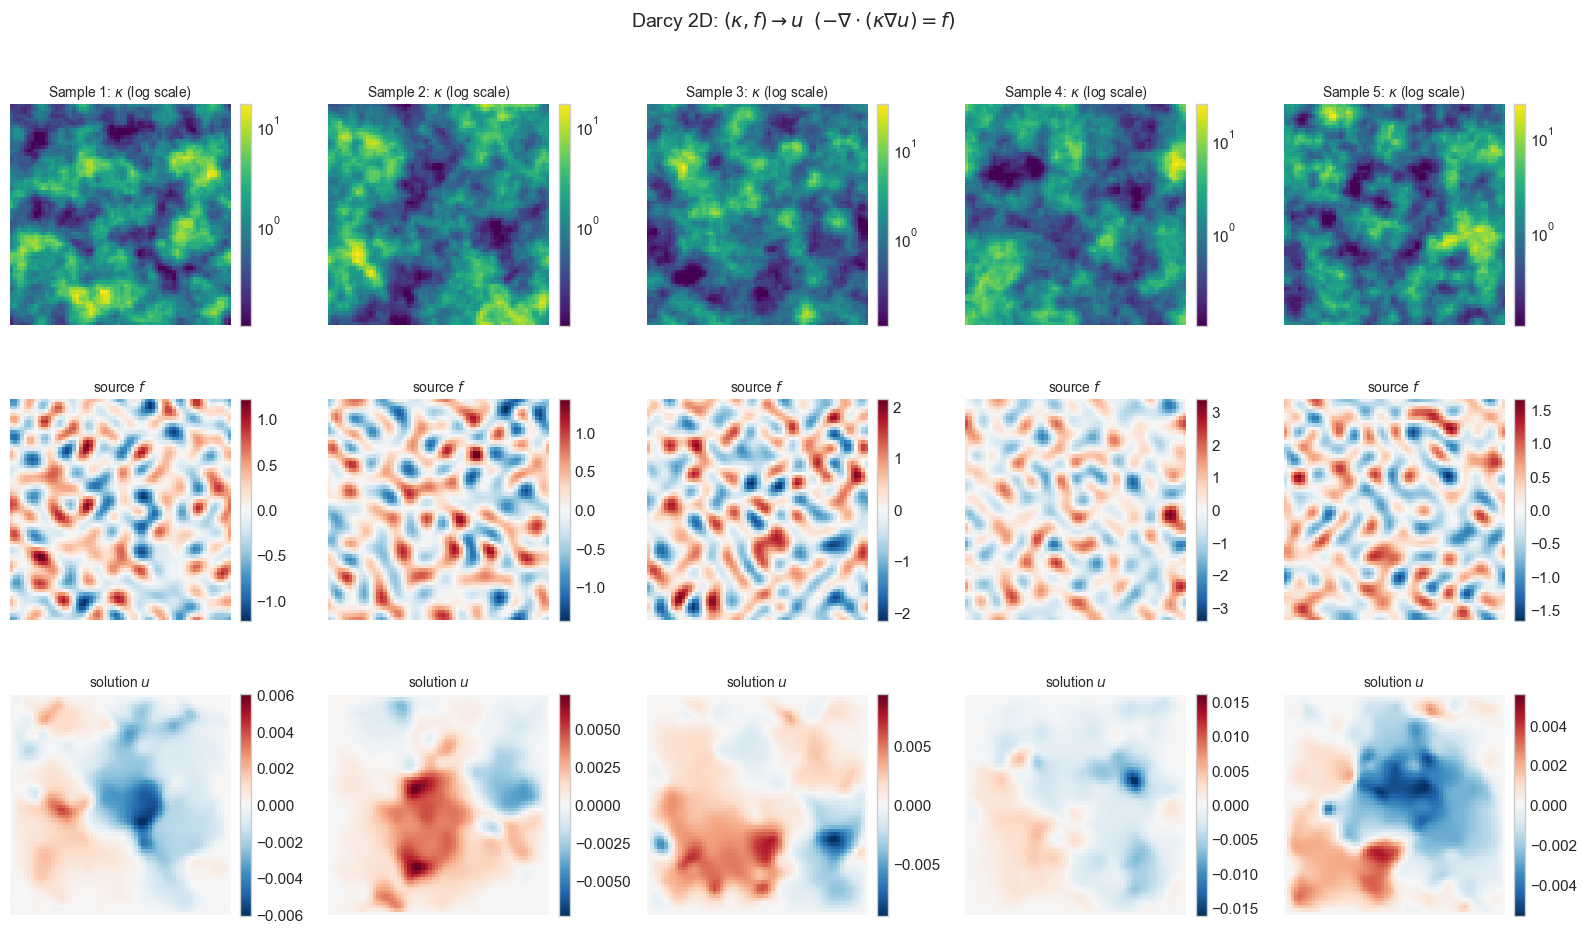

In [5]:
n_show = 5
fig, axes = plt.subplots(3, n_show, figsize=(3.2 * n_show, 9.5))

for i in range(n_show):
    im0 = axes[0, i].imshow(kappa[i, 0], cmap='viridis', origin='lower',
                            norm=LogNorm(vmin=kappa[i, 0].min(), vmax=kappa[i, 0].max()))
    axes[0, i].set_title(f'Sample {i+1}: $\\kappa$ (log scale)', fontsize=10)
    axes[0, i].axis('off')
    plt.colorbar(im0, ax=axes[0, i], fraction=0.046, pad=0.04)

    vmax_f = np.abs(source[i, 0]).max()
    im1 = axes[1, i].imshow(source[i, 0], cmap='RdBu_r', origin='lower',
                            norm=TwoSlopeNorm(vcenter=0, vmin=-vmax_f, vmax=vmax_f))
    axes[1, i].set_title('source $f$', fontsize=10)
    axes[1, i].axis('off')
    plt.colorbar(im1, ax=axes[1, i], fraction=0.046, pad=0.04)

    vmax_u = np.abs(solution[i, 0]).max()
    im2 = axes[2, i].imshow(solution[i, 0], cmap='RdBu_r', origin='lower',
                            norm=TwoSlopeNorm(vcenter=0, vmin=-vmax_u, vmax=vmax_u))
    axes[2, i].set_title('solution $u$', fontsize=10)
    axes[2, i].axis('off')
    plt.colorbar(im2, ax=axes[2, i], fraction=0.046, pad=0.04)

plt.suptitle('Darcy 2D: $(\\kappa, f) \\rightarrow u$  $\\left(-\\nabla\\cdot(\\kappa\\nabla u) = f\\right)$',
             fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

## 4. Value & Norm Distributions

Pixel-value histograms and per-sample $L^2$-norm distributions. $\kappa$ is shown twice — raw (heavy right tail) and in log space (Gaussian, which is what it is by construction, apart from the `kappa_min` clip in the left tail).

The per-sample $\|f\|_2$ histogram is broad because `f_amplitude_min`/`f_amplitude_max` scale each source by a uniform draw in $[0.1, 5]$ *after* normalizing it to unit max — so amplitude is a genuine per-sample nuisance parameter, and $\|u\|_2$ inherits that spread.

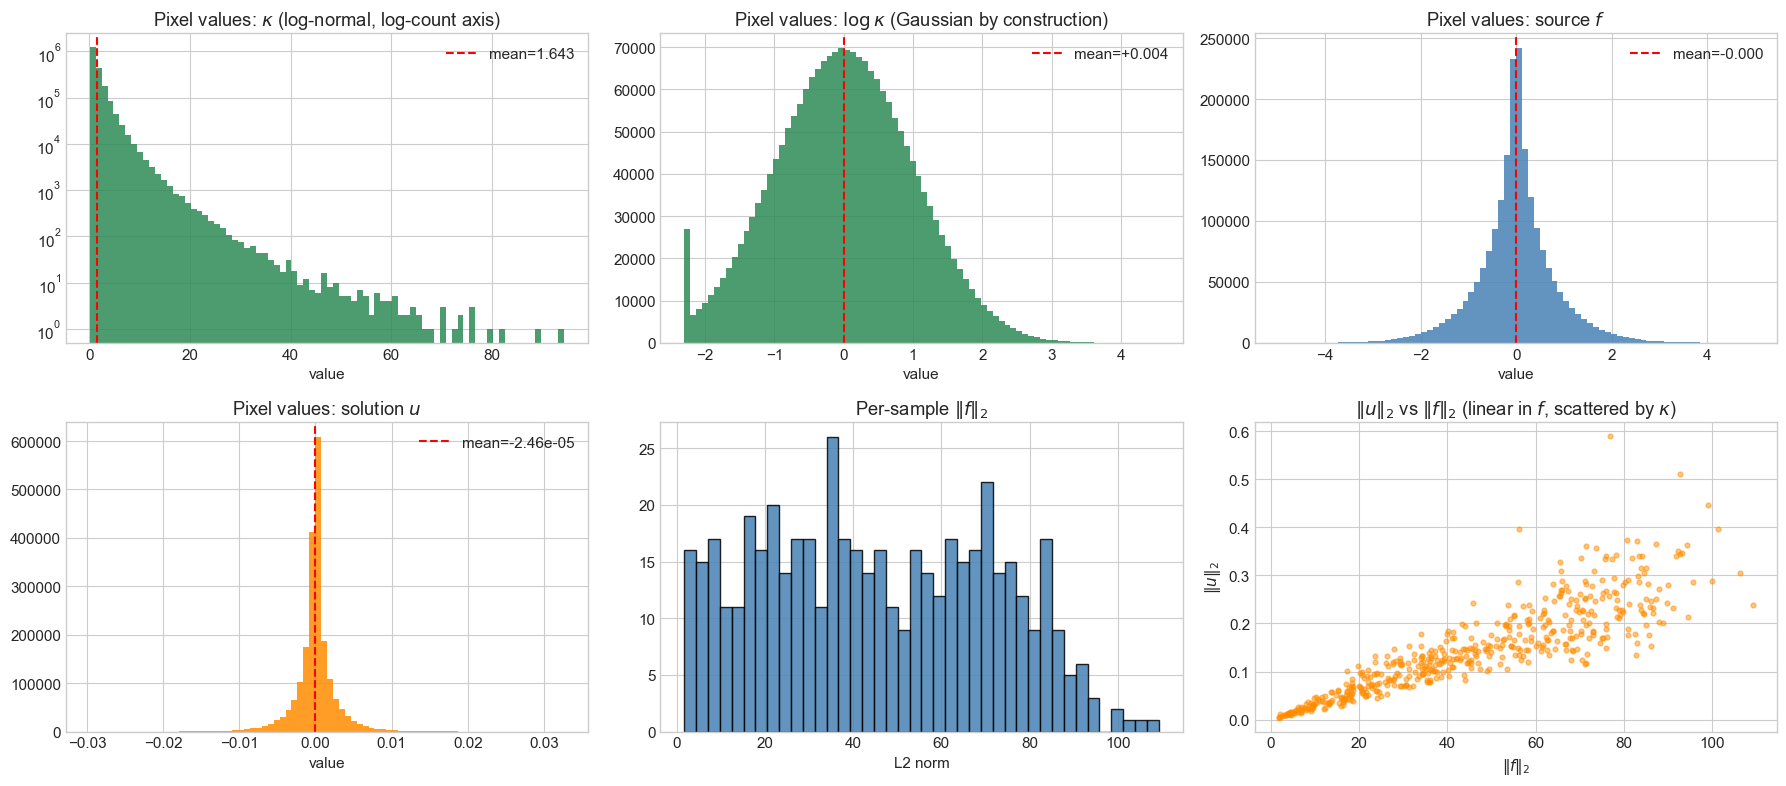

corr(||f||, ||u||) = 0.877  — the map is linear in f for fixed kappa, so the residual scatter is the kappa effect


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

axes[0, 0].hist(kappa.flatten(), bins=80, color='seagreen', edgecolor='none', alpha=0.85)
axes[0, 0].set_yscale('log')
axes[0, 0].axvline(kappa.mean(), color='red', linestyle='--', label=f'mean={kappa.mean():.3f}')
axes[0, 0].set_title('Pixel values: $\\kappa$ (log-normal, log-count axis)')
axes[0, 0].set_xlabel('value')
axes[0, 0].legend()

axes[0, 1].hist(log_kappa.flatten(), bins=80, color='seagreen', edgecolor='none', alpha=0.85)
axes[0, 1].axvline(log_kappa.mean(), color='red', linestyle='--', label=f'mean={log_kappa.mean():+.3f}')
axes[0, 1].set_title('Pixel values: $\\log\\kappa$ (Gaussian by construction)')
axes[0, 1].set_xlabel('value')
axes[0, 1].legend()

axes[0, 2].hist(source.flatten(), bins=80, color='steelblue', edgecolor='none', alpha=0.85)
axes[0, 2].axvline(source.mean(), color='red', linestyle='--', label=f'mean={source.mean():+.3f}')
axes[0, 2].set_title('Pixel values: source $f$')
axes[0, 2].set_xlabel('value')
axes[0, 2].legend()

axes[1, 0].hist(solution.flatten(), bins=80, color='darkorange', edgecolor='none', alpha=0.85)
axes[1, 0].axvline(solution.mean(), color='red', linestyle='--', label=f'mean={solution.mean():+.2e}')
axes[1, 0].set_title('Pixel values: solution $u$')
axes[1, 0].set_xlabel('value')
axes[1, 0].legend()

axes[1, 1].hist(source_norms, bins=40, color='steelblue', edgecolor='black', alpha=0.85)
axes[1, 1].set_title('Per-sample $\\|f\\|_2$')
axes[1, 1].set_xlabel('L2 norm')

axes[1, 2].scatter(source_norms, solution_norms, s=12, alpha=0.5, color='darkorange')
axes[1, 2].set_title('$\\|u\\|_2$ vs $\\|f\\|_2$ (linear in $f$, scattered by $\\kappa$)')
axes[1, 2].set_xlabel('$\\|f\\|_2$')
axes[1, 2].set_ylabel('$\\|u\\|_2$')

plt.tight_layout()
plt.show()

corr = np.corrcoef(source_norms, solution_norms)[0, 1]
print(f"corr(||f||, ||u||) = {corr:.3f}  "
      "— the map is linear in f for fixed kappa, so the residual scatter is the kappa effect")

## 5. Spatial Statistics — Pixel-wise Mean & Std Maps

$\kappa$ and $f$ are drawn from spatially stationary processes, so their pixel-wise mean/std maps should be featureless.

The solution is **not** stationary, and this is the structural difference from Poisson and Burgers: homogeneous Dirichlet conditions pin $u = 0$ on all four edges, so the std map must decay to zero at the boundary and peak in the interior. Any model for this dataset gets that boundary structure handed to it as a prior — worth remembering when reading relative-$L^2$ numbers, since a large fraction of the domain is near-zero by construction.

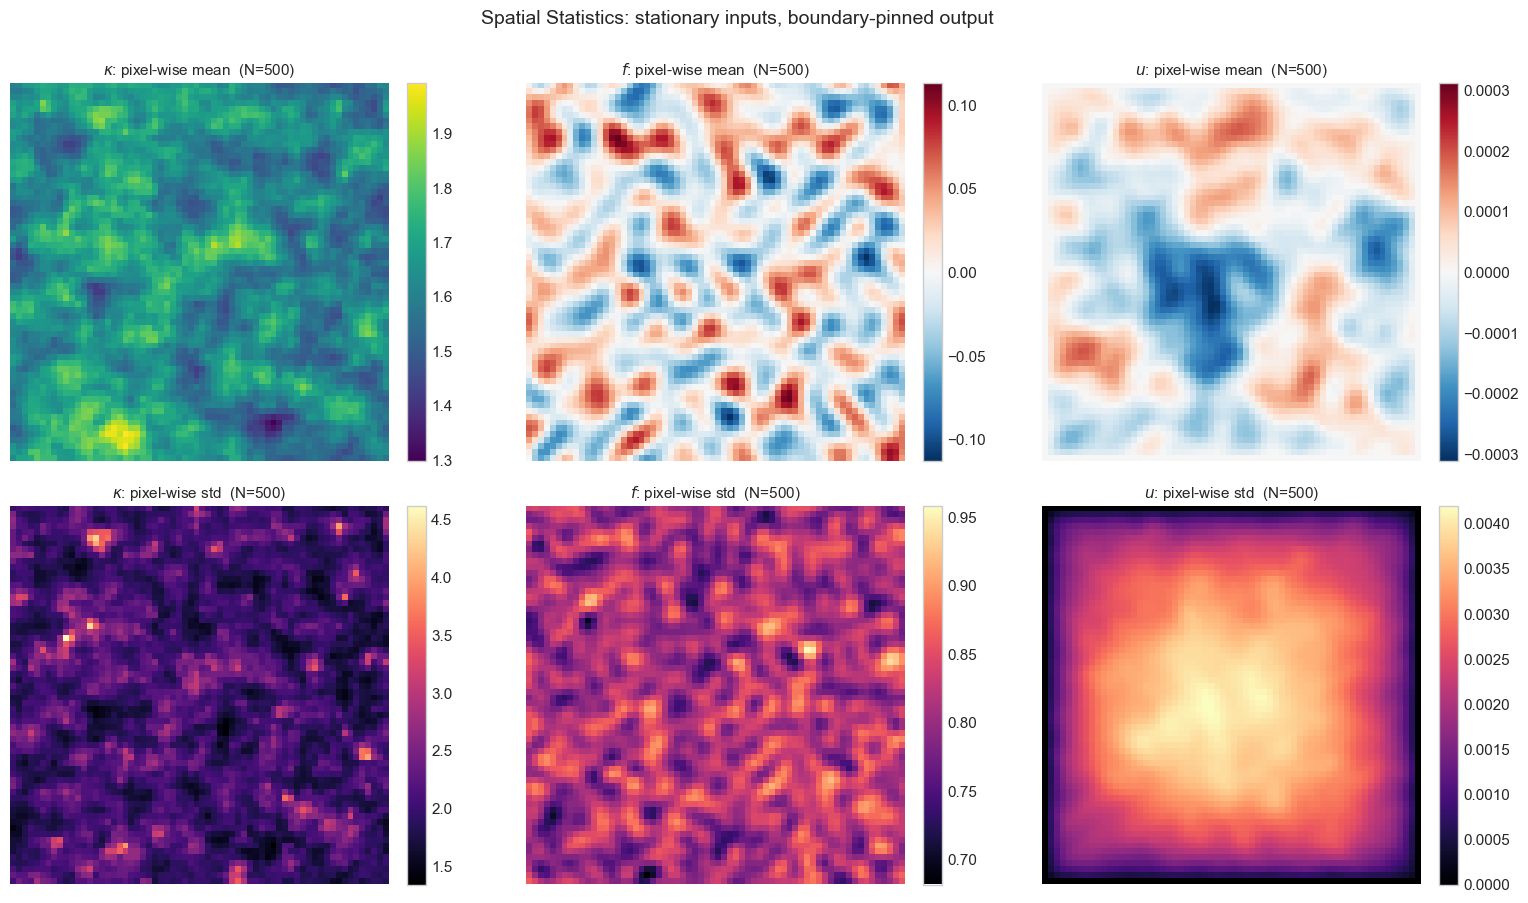

u std at the domain centre: 3.959e-03
u std one node in from the edge: 6.530e-04
u std on the edge itself: 0.000e+00  (Dirichlet)


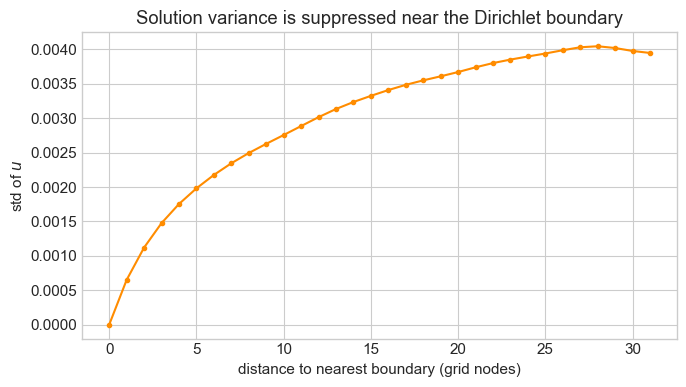

In [7]:
maps = [
    (kappa[:, 0].mean(axis=0), '$\\kappa$: pixel-wise mean', 'viridis', False),
    (source[:, 0].mean(axis=0), '$f$: pixel-wise mean', 'RdBu_r', True),
    (solution[:, 0].mean(axis=0), '$u$: pixel-wise mean', 'RdBu_r', True),
    (kappa[:, 0].std(axis=0), '$\\kappa$: pixel-wise std', 'magma', False),
    (source[:, 0].std(axis=0), '$f$: pixel-wise std', 'magma', False),
    (solution[:, 0].std(axis=0), '$u$: pixel-wise std', 'magma', False),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (field_map, title, cmap, diverging) in zip(axes.flat, maps):
    if diverging:
        vmax = max(np.abs(field_map).max(), 1e-12)
        im = ax.imshow(field_map, cmap=cmap, origin='lower',
                       norm=TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax))
    else:
        im = ax.imshow(field_map, cmap=cmap, origin='lower')
    ax.set_title(f'{title}  (N={n_samples})', fontsize=11)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Spatial Statistics: stationary inputs, boundary-pinned output', fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

sol_std_map = solution[:, 0].std(axis=0)
print(f"u std at the domain centre: {sol_std_map[H // 2, W // 2]:.3e}")
print(f"u std one node in from the edge: {sol_std_map[1, W // 2]:.3e}")
print(f"u std on the edge itself: {sol_std_map[0, W // 2]:.3e}  (Dirichlet)")

# Radial profile of the solution std, edge -> centre
dist_to_edge = np.minimum.outer(np.minimum(np.arange(H), H - 1 - np.arange(H)),
                                np.minimum(np.arange(W), W - 1 - np.arange(W)))
profile = np.array([sol_std_map[dist_to_edge == d].mean() for d in range(H // 2)])
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(profile, 'o-', color='darkorange', markersize=3)
ax.set_xlabel('distance to nearest boundary (grid nodes)')
ax.set_ylabel('std of $u$')
ax.set_title('Solution variance is suppressed near the Dirichlet boundary')
plt.tight_layout()
plt.show()

## 6. Spectral Analysis — Does the $\kappa$ GRF Match Its Analytic Spectrum?

$\log\kappa$ is generated by filtering white noise with $\sqrt{S}$, where

$$S(|k|) \propto (\tau^2 + |k|^2)^{-\alpha}$$

on **integer** wavenumbers (the generator uses `fftfreq(N) * N`, i.e. index space, not domain-scaled frequencies). So the measured radially-averaged power spectrum of $\log\kappa$ should follow that curve, up to the per-sample standardisation constant. Checking it validates the GRF machinery rather than trusting it.

The source $f$ is a truncated Fourier series with cutoff `f_cutoff=8`, so its power should fall off a cliff past $|k| = 8$.

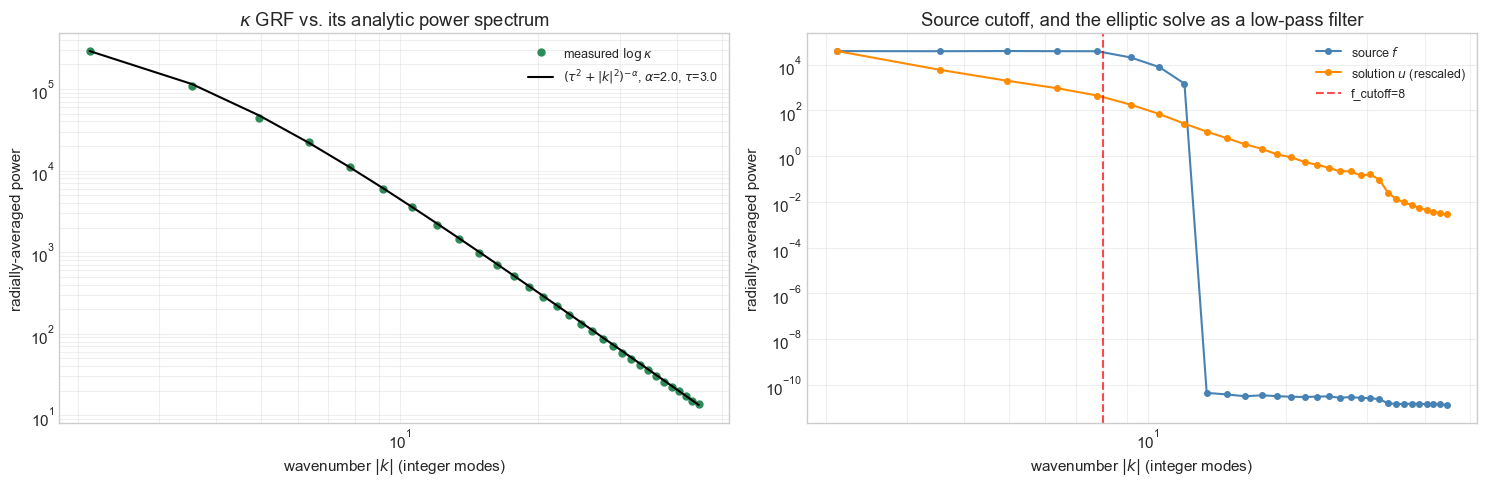

mean |log10 deviation| of the kappa spectrum from theory over k in [1,20]: 0.013 decades
source power above the cutoff, relative to peak: 9.46e-03


In [8]:
def radial_power_spectrum_index(fields):
    """Radially-averaged power spectrum on integer (index-space) wavenumbers.

    fields: (N, H, W) real array. Returns (k_centers, power) averaged over samples.
    """
    H, W = fields.shape[-2:]
    fft = np.fft.fft2(fields, axes=(-2, -1))
    power = (np.abs(fft) ** 2).mean(axis=0)

    freqs = np.fft.fftfreq(H) * H          # integer wavenumbers, matching the generator
    kx, ky = np.meshgrid(freqs, freqs, indexing='ij')
    kmag = np.sqrt(kx ** 2 + ky ** 2).flatten()
    power_flat = power.flatten()

    n_bins = H // 2
    bin_edges = np.linspace(0, kmag.max(), n_bins + 1)
    bin_idx = np.digitize(kmag, bin_edges)
    radial = np.array([
        power_flat[bin_idx == i].mean() if np.any(bin_idx == i) else np.nan
        for i in range(1, n_bins + 1)
    ])
    return 0.5 * (bin_edges[:-1] + bin_edges[1:]), radial


k_kap, p_kap = radial_power_spectrum_index(log_kappa[:, 0])
k_src, p_src = radial_power_spectrum_index(source[:, 0])
k_sol, p_sol = radial_power_spectrum_index(solution[:, 0])

# Analytic GRF spectrum, matched to the measured curve at the second bin
theory = (darcy_cfg.kappa_tau ** 2 + k_kap ** 2) ** (-darcy_cfg.kappa_alpha)
theory = theory * (p_kap[1] / theory[1])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].loglog(k_kap[1:], p_kap[1:], 'o', color='seagreen', markersize=5, label='measured $\\log\\kappa$')
axes[0].loglog(k_kap[1:], theory[1:], '-', color='black', linewidth=1.5,
               label=f'$(\\tau^2+|k|^2)^{{-\\alpha}}$, $\\alpha$={darcy_cfg.kappa_alpha}, $\\tau$={darcy_cfg.kappa_tau}')
axes[0].set_xlabel('wavenumber $|k|$ (integer modes)')
axes[0].set_ylabel('radially-averaged power')
axes[0].set_title('$\\kappa$ GRF vs. its analytic power spectrum')
axes[0].legend(fontsize=9)
axes[0].grid(True, which='both', alpha=0.3)

axes[1].loglog(k_src[1:], p_src[1:], 'o-', color='steelblue', markersize=4, label='source $f$')
axes[1].loglog(k_sol[1:], p_sol[1:] / p_sol[1] * p_src[1], 'o-', color='darkorange',
               markersize=4, label='solution $u$ (rescaled)')
axes[1].axvline(darcy_cfg.f_cutoff, color='red', linestyle='--', alpha=0.7,
                label=f'f_cutoff={darcy_cfg.f_cutoff}')
axes[1].set_xlabel('wavenumber $|k|$ (integer modes)')
axes[1].set_ylabel('radially-averaged power')
axes[1].set_title('Source cutoff, and the elliptic solve as a low-pass filter')
axes[1].legend(fontsize=9)
axes[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

rel_dev = np.abs(np.log10(p_kap[1:20]) - np.log10(theory[1:20])).mean()
print(f"mean |log10 deviation| of the kappa spectrum from theory over k in [1,20]: {rel_dev:.3f} decades")
print(f"source power above the cutoff, relative to peak: "
      f"{np.nanmean(p_src[k_src > darcy_cfg.f_cutoff + 2]) / p_src[1]:.2e}")

## 7. Sanity Check — Do the Pairs Satisfy $-\nabla\cdot(\kappa\nabla u) = f$?

We reimplement the five-point finite-difference operator with arithmetic interface averaging,

$$(A u)_{ij} = \frac{1}{h^2}\Big[(\kappa_{i+\frac12,j}+\kappa_{i-\frac12,j}+\kappa_{i,j+\frac12}+\kappa_{i,j-\frac12})u_{ij} - \kappa_{i+\frac12,j}u_{i+1,j} - \kappa_{i-\frac12,j}u_{i-1,j} - \kappa_{i,j+\frac12}u_{i,j+1} - \kappa_{i,j-\frac12}u_{i,j-1}\Big],$$

apply it to the stored solution, and compare against $f$ on the interior nodes (the only ones the solver actually solves for).

Unlike the Poisson spectral solve, this residual will **not** be at machine precision: the generator runs a *fixed* number of CG iterations with no convergence check, so what we are measuring is how far CG got. §8 turns that into a sweep.

max |f| (interior):     4.9678
max |residual|:         4.772e-01
global relative L2:     2.266e-03
per-sample relative L2: median=1.685e-04  p95=3.651e-03  max=2.662e-02


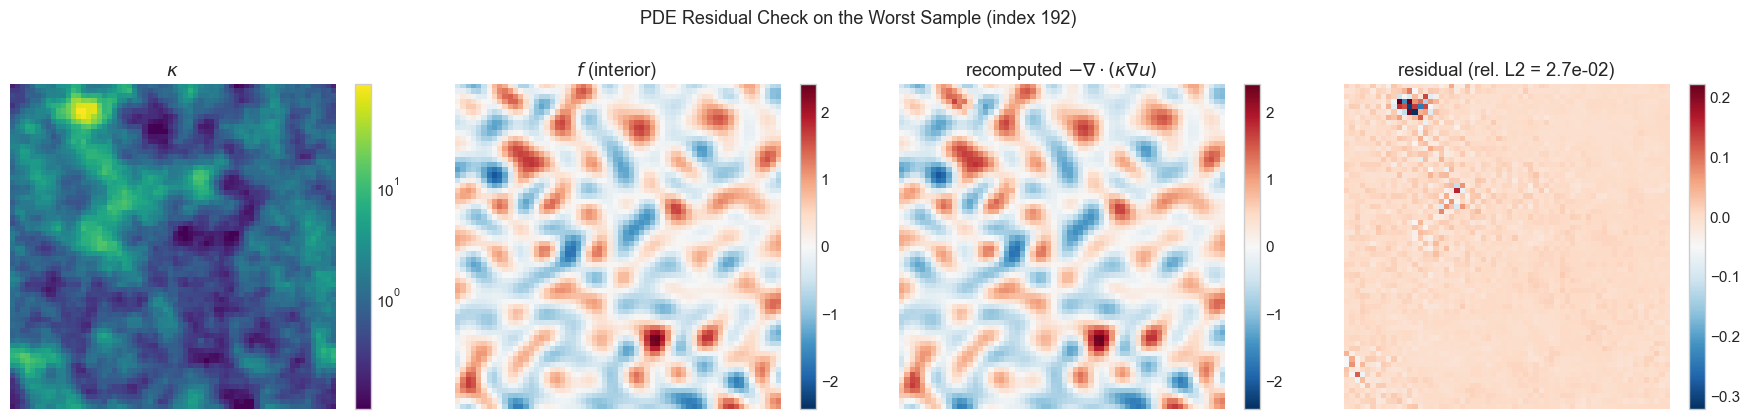

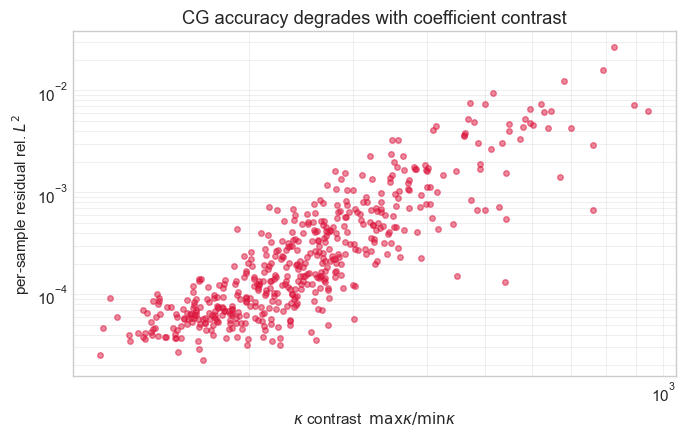

corr(log contrast, log residual) = 0.860


In [9]:
def darcy_operator_2d(u, kap, h):
    """Apply -div(kappa grad .) on interior nodes. u, kap: (N, H, W). Returns (N, H-2, W-2)."""
    ki = kap[:, 1:-1, 1:-1]
    kx_r = 0.5 * (ki + kap[:, 2:,   1:-1])     # kappa_{i+1/2, j}
    kx_l = 0.5 * (ki + kap[:, :-2,  1:-1])     # kappa_{i-1/2, j}
    ky_u = 0.5 * (ki + kap[:, 1:-1, 2:  ])     # kappa_{i, j+1/2}
    ky_d = 0.5 * (ki + kap[:, 1:-1, :-2 ])     # kappa_{i, j-1/2}
    return (
        (kx_r + kx_l + ky_u + ky_d) * u[:, 1:-1, 1:-1]
        - kx_r * u[:, 2:,   1:-1]
        - kx_l * u[:, :-2,  1:-1]
        - ky_u * u[:, 1:-1, 2:  ]
        - ky_d * u[:, 1:-1, :-2 ]
    ) / h ** 2


Au = darcy_operator_2d(solution[:, 0], kappa[:, 0], h)
f_int = source[:, 0, 1:-1, 1:-1]
residual = Au - f_int

per_sample_rel = (np.linalg.norm(residual.reshape(n_samples, -1), axis=-1)
                  / np.linalg.norm(f_int.reshape(n_samples, -1), axis=-1))

print(f"max |f| (interior):     {np.abs(f_int).max():.4f}")
print(f"max |residual|:         {np.abs(residual).max():.3e}")
print(f"global relative L2:     {np.linalg.norm(residual) / np.linalg.norm(f_int):.3e}")
print(f"per-sample relative L2: median={np.median(per_sample_rel):.3e}  "
      f"p95={np.percentile(per_sample_rel, 95):.3e}  max={per_sample_rel.max():.3e}")

# Visual check on the worst sample, where the solver did least well
i = int(np.argmax(per_sample_rel))
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
vmax = np.abs(f_int[i]).max()

im0 = axes[0].imshow(kappa[i, 0], cmap='viridis', origin='lower',
                     norm=LogNorm(vmin=kappa[i, 0].min(), vmax=kappa[i, 0].max()))
axes[0].set_title('$\\kappa$')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(f_int[i], cmap='RdBu_r', origin='lower',
                     norm=TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax))
axes[1].set_title('$f$ (interior)')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(Au[i], cmap='RdBu_r', origin='lower',
                     norm=TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax))
axes[2].set_title('recomputed $-\\nabla\\cdot(\\kappa\\nabla u)$')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

im3 = axes[3].imshow(residual[i], cmap='RdBu_r', origin='lower')
axes[3].set_title(f'residual (rel. L2 = {per_sample_rel[i]:.1e})')
plt.colorbar(im3, ax=axes[3], fraction=0.046)

for ax in axes:
    ax.axis('off')
plt.suptitle(f'PDE Residual Check on the Worst Sample (index {i})', fontsize=13, y=1.04)
plt.tight_layout()
plt.show()

# Does solver error track the coefficient contrast? Ill-conditioned kappa -> slower CG.
contrast = kappa.reshape(n_samples, -1).max(-1) / kappa.reshape(n_samples, -1).min(-1)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(contrast, per_sample_rel, 'o', markersize=4, alpha=0.5, color='crimson')
ax.set_xlabel('$\\kappa$ contrast  $\\max\\kappa / \\min\\kappa$')
ax.set_ylabel('per-sample residual rel. $L^2$')
ax.set_title('CG accuracy degrades with coefficient contrast')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()
print(f"corr(log contrast, log residual) = "
      f"{np.corrcoef(np.log(contrast), np.log(per_sample_rel))[0, 1]:.3f}")

## 8. How Many CG Steps Does the Solver Actually Need?

`cg_steps` is a fixed iteration count with no convergence check — that is what keeps the solve `jax.vmap`-compatible, but it means **the number is a correctness parameter, not a speed knob**. The docstring suggests dropping to ~100 "for fast prototyping"; the sweep below shows what that buys you.

Re-generating with the same seed at each `cg_steps` keeps $\kappa$ and $f$ fixed, so the only thing changing is how converged $u$ is.

Generated Darcy 2D dataset: 16 samples, 64x64 grid, κ ~ LogNormal(α=2.0, τ=3.0, scale=1.0), CG steps=50
Generated Darcy 2D dataset: 16 samples, 64x64 grid, κ ~ LogNormal(α=2.0, τ=3.0, scale=1.0), CG steps=100
Generated Darcy 2D dataset: 16 samples, 64x64 grid, κ ~ LogNormal(α=2.0, τ=3.0, scale=1.0), CG steps=200
Generated Darcy 2D dataset: 16 samples, 64x64 grid, κ ~ LogNormal(α=2.0, τ=3.0, scale=1.0), CG steps=500
Generated Darcy 2D dataset: 16 samples, 64x64 grid, κ ~ LogNormal(α=2.0, τ=3.0, scale=1.0), CG steps=1000
Generated Darcy 2D dataset: 16 samples, 64x64 grid, κ ~ LogNormal(α=2.0, τ=3.0, scale=1.0), CG steps=2000
 cg_steps   residual rel L2   ||u - u_ref|| / ||u_ref||
Generated Darcy 2D dataset: 16 samples, 64x64 grid, κ ~ LogNormal(α=2.0, τ=3.0, scale=1.0), CG steps=50
       50         7.230e-01                   6.439e-01
Generated Darcy 2D dataset: 16 samples, 64x64 grid, κ ~ LogNormal(α=2.0, τ=3.0, scale=1.0), CG steps=100
      100         3.563e-01                   3.

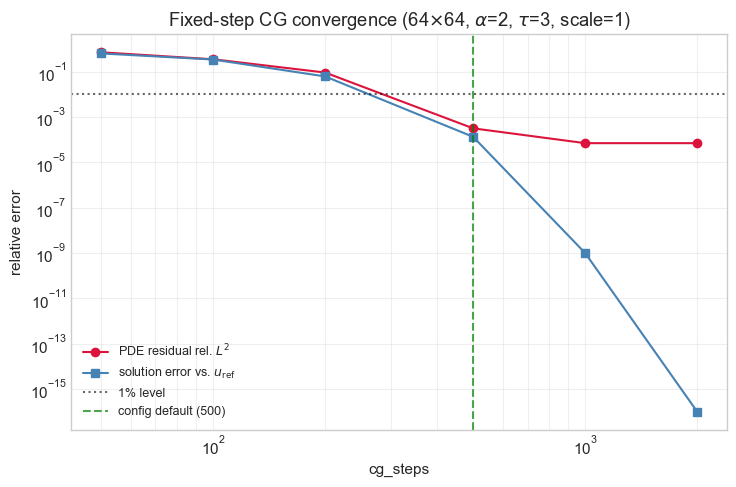

In [10]:
cg_sweep = [50, 100, 200, 500, 1000, 2000]
sweep_n = 16
cg_residuals = []
u_ref = None

for cg in cg_sweep:
    cfg_cg = DarcyConfig(
        num_spatial_dims=2, num_points=64, domain_extent=1.0,
        num_samples=sweep_n, seed=42,
        kappa_alpha=2.0, kappa_tau=3.0, kappa_scale=1.0,
        f_cutoff=8, f_amplitude_min=0.1, f_amplitude_max=5.0,
        cg_steps=cg,
    )
    d_cg = DarcyGenerator(config=cfg_cg).generate().get_raw_data()
    k_cg = d_cg['kappa'][:, 0].numpy()
    f_cg = d_cg['source'][:, 0].numpy()
    u_cg = d_cg['solution'][:, 0].numpy()

    r_cg = darcy_operator_2d(u_cg, k_cg, h) - f_cg[:, 1:-1, 1:-1]
    rel = np.linalg.norm(r_cg) / np.linalg.norm(f_cg[:, 1:-1, 1:-1])
    cg_residuals.append(rel)
    if cg == cg_sweep[-1]:
        u_ref = u_cg   # treat the most-converged run as the reference solution

print(f"{'cg_steps':>9s}  {'residual rel L2':>16s}  {'||u - u_ref|| / ||u_ref||':>26s}")
u_errors = []
for cg, rel in zip(cg_sweep, cg_residuals):
    cfg_cg = DarcyConfig(
        num_spatial_dims=2, num_points=64, domain_extent=1.0,
        num_samples=sweep_n, seed=42,
        kappa_alpha=2.0, kappa_tau=3.0, kappa_scale=1.0,
        f_cutoff=8, f_amplitude_min=0.1, f_amplitude_max=5.0,
        cg_steps=cg,
    )
    u_cg = DarcyGenerator(config=cfg_cg).generate().get_raw_data()['solution'][:, 0].numpy()
    u_err = np.linalg.norm(u_cg - u_ref) / np.linalg.norm(u_ref)
    u_errors.append(u_err)
    print(f"{cg:>9d}  {rel:>16.3e}  {u_err:>26.3e}")

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.loglog(cg_sweep, cg_residuals, 'o-', color='crimson', label='PDE residual rel. $L^2$')
ax.loglog(cg_sweep, np.maximum(u_errors, 1e-16), 's-', color='steelblue',
          label='solution error vs. $u_{\\mathrm{ref}}$')
ax.axhline(1e-2, color='black', linestyle=':', alpha=0.6, label='1% level')
ax.axvline(darcy_cfg.cg_steps, color='green', linestyle='--', alpha=0.7,
           label=f'config default ({darcy_cfg.cg_steps})')
ax.set_xlabel('cg_steps')
ax.set_ylabel('relative error')
ax.set_title('Fixed-step CG convergence (64$\\times$64, $\\alpha$=2, $\\tau$=3, scale=1)')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

**Takeaway:** at 64×64 with this coefficient contrast, `cg_steps=100` leaves a solution that is *wrong by tens of percent* — a dataset generated that way is not the Darcy operator, it is "100 CG iterations applied to the Darcy operator", and a model trained on it would learn that instead. The default of 500 is where the residual becomes small; anything used for reported results should sit at or above it, and a finer grid or a larger `kappa_scale` needs more (the condition number grows with both). Reduce it only for wiring checks, never for a run you intend to cite.

## 9. Effect of `kappa_alpha`, `kappa_tau`, `kappa_scale`

The three GRF knobs do different things:

- **`kappa_alpha`** — spectral decay exponent. Higher $\alpha$ suppresses high wavenumbers, giving a *smoother* $\kappa$.
- **`kappa_tau`** — inverse correlation length. Higher $\tau$ flattens the low-$k$ end of $(\tau^2 + |k|^2)^{-\alpha}$, pushing energy toward smaller features.
- **`kappa_scale`** — std of $\log\kappa$. This sets the **contrast**, and therefore the conditioning of the linear system: it controls difficulty far more directly than the other two.

Generated Darcy 2D dataset: 8 samples, 64x64 grid, κ ~ LogNormal(α=2.0, τ=3.0, scale=1.0), CG steps=1000
Generated Darcy 2D dataset: 8 samples, 64x64 grid, κ ~ LogNormal(α=3.5, τ=3.0, scale=1.0), CG steps=1000
Generated Darcy 2D dataset: 8 samples, 64x64 grid, κ ~ LogNormal(α=2.0, τ=8.0, scale=1.0), CG steps=1000
Generated Darcy 2D dataset: 8 samples, 64x64 grid, κ ~ LogNormal(α=2.0, τ=3.0, scale=2.0), CG steps=1000


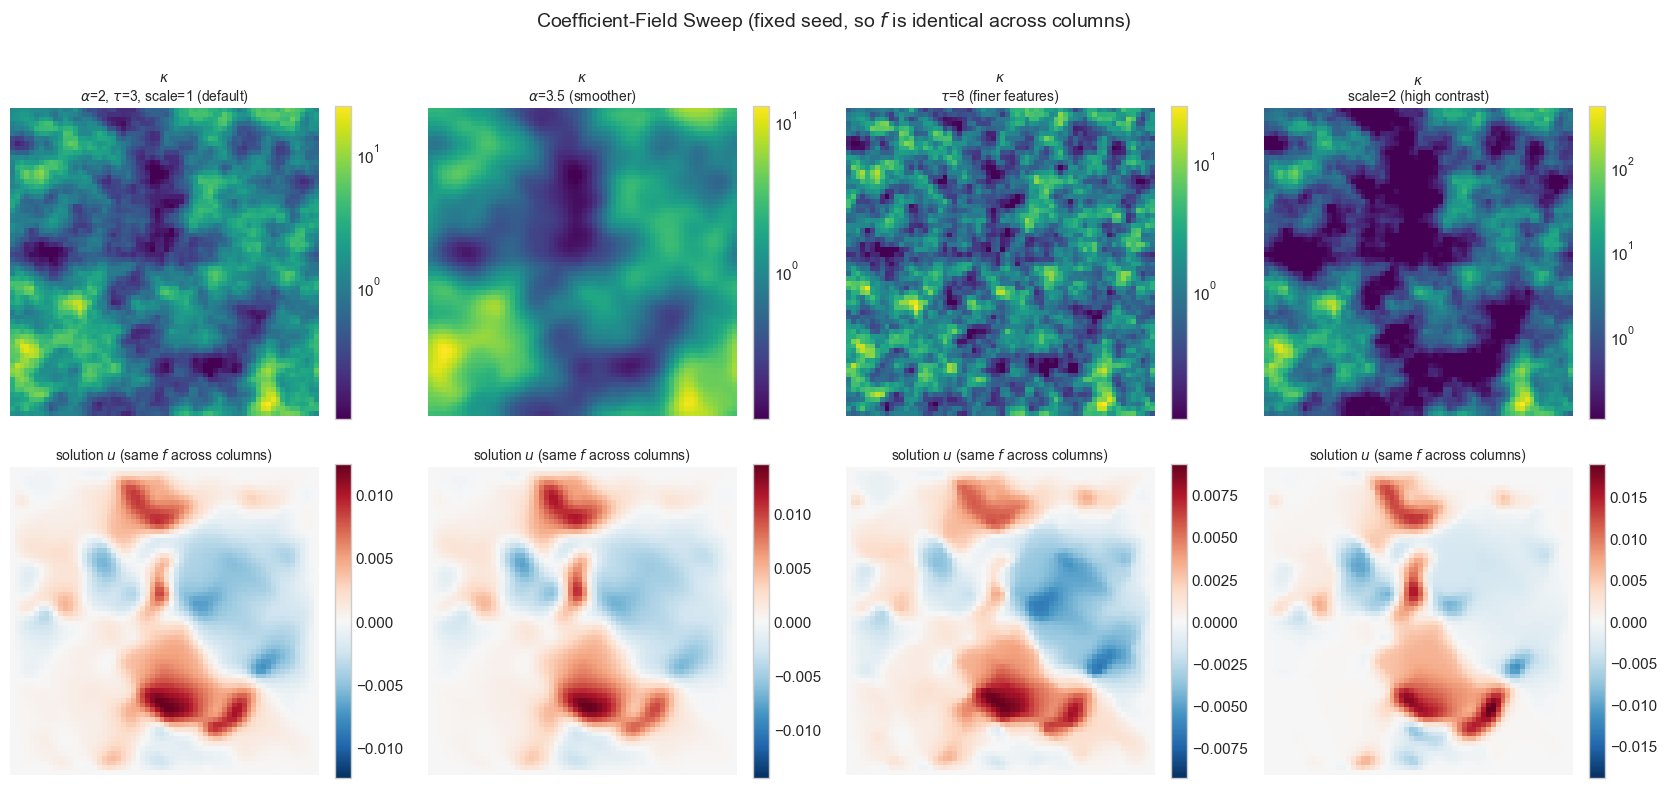

                                 setting   mean contrast   residual @ cg=1000
       alpha=2, tau=3, scale=1 (default)           180.4             7.46e-05
                    alpha=3.5 (smoother)           104.8             5.26e-05
                  tau=8 (finer features)           293.4             7.29e-05
                 scale=2 (high contrast)          3294.7             5.90e-02


In [11]:
kappa_sweeps = [
    dict(kappa_alpha=2.0, kappa_tau=3.0, kappa_scale=1.0, label='$\\alpha$=2, $\\tau$=3, scale=1 (default)'),
    dict(kappa_alpha=3.5, kappa_tau=3.0, kappa_scale=1.0, label='$\\alpha$=3.5 (smoother)'),
    dict(kappa_alpha=2.0, kappa_tau=8.0, kappa_scale=1.0, label='$\\tau$=8 (finer features)'),
    dict(kappa_alpha=2.0, kappa_tau=3.0, kappa_scale=2.0, label='scale=2 (high contrast)'),
]

fig, axes = plt.subplots(2, len(kappa_sweeps), figsize=(4.2 * len(kappa_sweeps), 8))
sweep_stats = []

for j, sweep in enumerate(kappa_sweeps):
    cfg_j = DarcyConfig(
        num_spatial_dims=2, num_points=64, domain_extent=1.0,
        num_samples=8, seed=0,
        kappa_alpha=sweep['kappa_alpha'],
        kappa_tau=sweep['kappa_tau'],
        kappa_scale=sweep['kappa_scale'],
        f_cutoff=8, f_amplitude_min=0.1, f_amplitude_max=5.0,
        cg_steps=1000,
    )
    d_j = DarcyGenerator(config=cfg_j).generate().get_raw_data()
    k_j = d_j['kappa'][:, 0].numpy()
    f_j = d_j['source'][:, 0].numpy()
    u_j = d_j['solution'][:, 0].numpy()

    im0 = axes[0, j].imshow(k_j[0], cmap='viridis', origin='lower',
                            norm=LogNorm(vmin=k_j[0].min(), vmax=k_j[0].max()))
    axes[0, j].set_title(f"$\\kappa$\n{sweep['label']}", fontsize=10)
    axes[0, j].axis('off')
    plt.colorbar(im0, ax=axes[0, j], fraction=0.046)

    vmax_u = np.abs(u_j[0]).max()
    im1 = axes[1, j].imshow(u_j[0], cmap='RdBu_r', origin='lower',
                            norm=TwoSlopeNorm(vcenter=0, vmin=-vmax_u, vmax=vmax_u))
    axes[1, j].set_title('solution $u$ (same $f$ across columns)', fontsize=10)
    axes[1, j].axis('off')
    plt.colorbar(im1, ax=axes[1, j], fraction=0.046)

    r_j = darcy_operator_2d(u_j, k_j, h) - f_j[:, 1:-1, 1:-1]
    sweep_stats.append((
        sweep['label'],
        k_j.reshape(len(k_j), -1).max(-1).mean() / k_j.reshape(len(k_j), -1).min(-1).mean(),
        np.linalg.norm(r_j) / np.linalg.norm(f_j[:, 1:-1, 1:-1]),
    ))

plt.suptitle('Coefficient-Field Sweep (fixed seed, so $f$ is identical across columns)',
             fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

print(f"{'setting':>40s}  {'mean contrast':>14s}  {'residual @ cg=1000':>19s}")
for label, contrast_j, res_j in sweep_stats:
    plain = label.replace('$\\alpha$', 'alpha').replace('$\\tau$', 'tau').replace('\\', '')
    print(f"{plain:>40s}  {contrast_j:>14.1f}  {res_j:>19.2e}")

## 10. The Three Inverse Problems

Darcy has more inverse structure than the other datasets, because there are two PDE inputs to recover. `generate(problem='inverse', inverse_mode=...)` gives three distinct mappings:

| `inverse_mode` | input | target |
|---|---|---|
| `'both'` | $u$ | $(\kappa, f)$ |
| `'coefficient'` | $(u, f)$ | $\kappa$ |
| `'source'` | $(u, \kappa)$ | $f$ |

`'both'` is the genuinely ill-posed one — $u$ alone cannot separate the coefficient from the source, since scaling $\kappa$ and $f$ together leaves $u$ unchanged. That non-identifiability is a *feature* for the UQ story: the posterior is broad for real reasons, not just from noise.

**A scale gotcha specific to Darcy:** `obs_noise_std` is an absolute noise level applied to $u$, and here $\mathrm{std}(u) \approx 3\times 10^{-3}$. Passing the `obs_noise_std=0.02` used in the Poisson and Burgers notebooks would bury the signal under noise roughly seven times its size. Set it relative to the measured field scale instead.

In [12]:
u_std = float(stats['solution']['std'])
noise_level = 0.05 * u_std      # 5% of the solution scale, not an absolute 0.02
print(f"std(u) = {u_std:.3e}  ->  using obs_noise_std = {noise_level:.3e} (5% of field scale)")
print(f"(the Poisson/Burgers value of 0.02 would be {0.02 / u_std:.0f}x the signal std)\n")

inv_datasets = {}
for mode in ['both', 'coefficient', 'source']:
    cfg_inv = DarcyConfig(
        num_spatial_dims=2, num_points=64, domain_extent=1.0,
        num_samples=8, seed=42,          # same seed -> same underlying (kappa, f, u)
        kappa_alpha=2.0, kappa_tau=3.0, kappa_scale=1.0,
        f_cutoff=8, f_amplitude_min=0.1, f_amplitude_max=5.0,
        cg_steps=500,
        obs_noise_std=noise_level,
        obs_mask_fraction=0.4,           # only 40% of grid points observed
    )
    ds_inv = DarcyGenerator(config=cfg_inv).generate(problem='inverse', inverse_mode=mode)
    inv_datasets[mode] = ds_inv
    s = ds_inv[0]
    print(f"inverse_mode={mode:>12s}: input {tuple(s['input'].shape)} "
          f"[{', '.join(ds_inv.input_fields)} + mask]  ->  "
          f"target {tuple(s['target'].shape)} [{', '.join(ds_inv.target_fields)}]")

print(f"\nData keys: {list(inv_datasets['both'].get_raw_data().keys())}")

std(u) = 2.687e-03  ->  using obs_noise_std = 1.344e-04 (5% of field scale)
(the Poisson/Burgers value of 0.02 would be 7x the signal std)

Generated Darcy 2D dataset: 8 samples, 64x64 grid, κ ~ LogNormal(α=2.0, τ=3.0, scale=1.0), CG steps=500
inverse_mode=        both: input (2, 64, 64) [solution + mask]  ->  target (2, 64, 64) [kappa, source]
Generated Darcy 2D dataset: 8 samples, 64x64 grid, κ ~ LogNormal(α=2.0, τ=3.0, scale=1.0), CG steps=500
inverse_mode= coefficient: input (3, 64, 64) [solution, source + mask]  ->  target (1, 64, 64) [kappa]
Generated Darcy 2D dataset: 8 samples, 64x64 grid, κ ~ LogNormal(α=2.0, τ=3.0, scale=1.0), CG steps=500
inverse_mode=      source: input (3, 64, 64) [solution, kappa + mask]  ->  target (1, 64, 64) [source]

Data keys: ['kappa', 'source', 'solution', 'obs_mask']


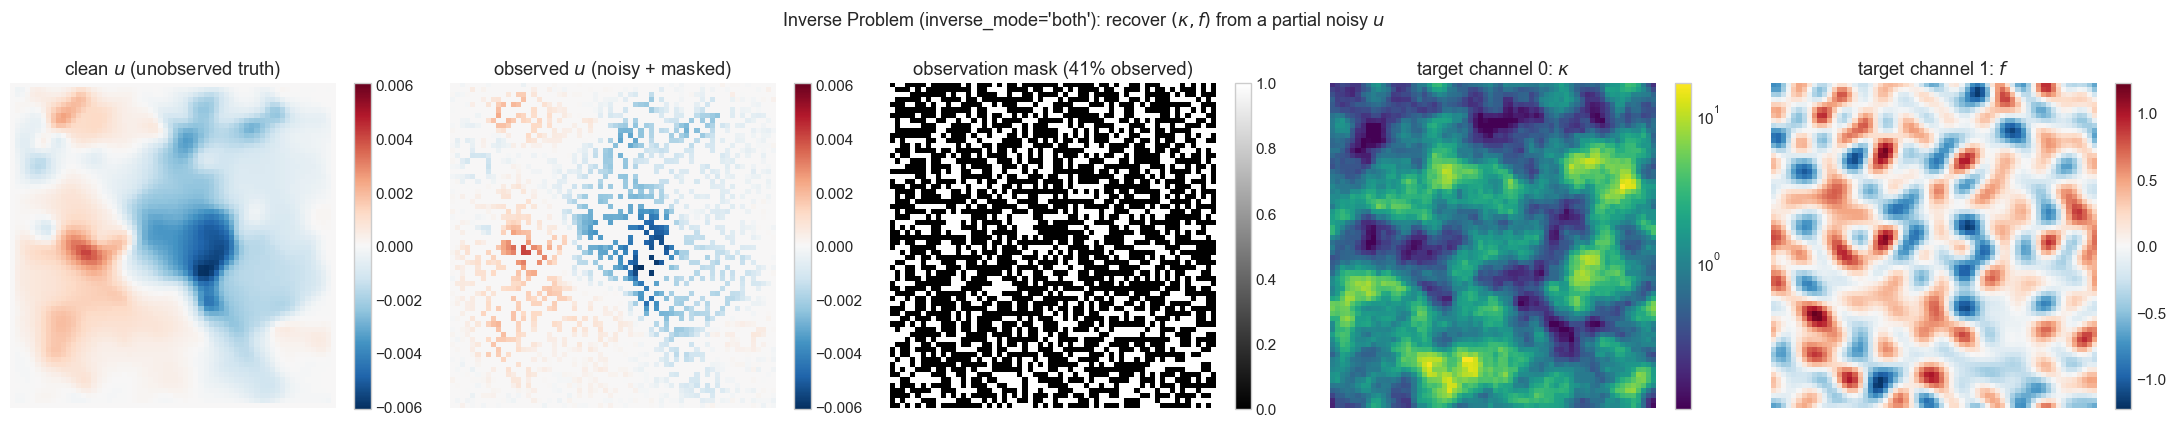

SNR on observed pixels: 10.4
masked-out fraction: 59%  (masked pixels are zeroed, and the mask rides along as an extra input channel)


In [13]:
ds_both = inv_datasets['both']
sample_inv = ds_both[0]
raw_inv = ds_both.get_raw_data()

obs_field = sample_inv['input'][0].numpy()      # noisy, masked solution
mask = sample_inv['obs_mask'][0].numpy()
target_kappa = sample_inv['target'][0].numpy()
target_source = sample_inv['target'][1].numpy()
clean_u = solution[0, 0]                        # same seed -> same clean solution

fig, axes = plt.subplots(1, 5, figsize=(22, 4))

vmax_u = np.abs(clean_u).max()
im0 = axes[0].imshow(clean_u, cmap='RdBu_r', origin='lower',
                     norm=TwoSlopeNorm(vcenter=0, vmin=-vmax_u, vmax=vmax_u))
axes[0].set_title('clean $u$ (unobserved truth)')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(obs_field, cmap='RdBu_r', origin='lower',
                     norm=TwoSlopeNorm(vcenter=0, vmin=-vmax_u, vmax=vmax_u))
axes[1].set_title('observed $u$ (noisy + masked)')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(mask, cmap='gray', origin='lower', vmin=0, vmax=1)
axes[2].set_title(f'observation mask ({mask.mean() * 100:.0f}% observed)')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

im3 = axes[3].imshow(target_kappa, cmap='viridis', origin='lower',
                     norm=LogNorm(vmin=target_kappa.min(), vmax=target_kappa.max()))
axes[3].set_title('target channel 0: $\\kappa$')
plt.colorbar(im3, ax=axes[3], fraction=0.046)

vmax_f = np.abs(target_source).max()
im4 = axes[4].imshow(target_source, cmap='RdBu_r', origin='lower',
                     norm=TwoSlopeNorm(vcenter=0, vmin=-vmax_f, vmax=vmax_f))
axes[4].set_title('target channel 1: $f$')
plt.colorbar(im4, ax=axes[4], fraction=0.046)

for ax in axes:
    ax.axis('off')
plt.suptitle("Inverse Problem (inverse_mode='both'): recover $(\\kappa, f)$ from a partial noisy $u$",
             fontsize=13, y=1.04)
plt.tight_layout()
plt.show()

# How much signal survives the corruption?
observed_only = obs_field[mask > 0]
clean_observed = clean_u[mask > 0]
snr = clean_observed.std() / (observed_only - clean_observed).std()
print(f"SNR on observed pixels: {snr:.1f}")
print(f"masked-out fraction: {(1 - mask.mean()) * 100:.0f}%  "
      "(masked pixels are zeroed, and the mask rides along as an extra input channel)")

## 11. Field Normalization

This is where the scale gap from §2 has to be dealt with. $\kappa \sim \mathcal{O}(1)$, $f \sim \mathcal{O}(1)$, and $u \sim \mathcal{O}(10^{-3})$; flow matching transports $\mathcal{N}(0, I)$ to the data, so an unnormalized target three orders of magnitude below unit scale makes the velocity regression hopeless.

`FieldNormalizer` standardizes each field independently, **keyed by raw field name** (`kappa`, `source`, `solution`) rather than by role. That is what lets one normalizer stay correct across `problem='forward'` and every `inverse_mode` — the same instance is reused verbatim on val/test, never refit.

Note that $\kappa$ is standardized in *linear* space, not log space, so the normalized $\kappa$ channel keeps its log-normal skew. Working with $\log\kappa$ as the learned target is a modeling choice worth testing separately; the dataset does not make it for you.

In [14]:
normalizer = FieldNormalizer.from_dataset(darcy_dataset)
darcy_dataset.set_normalizer(normalizer)

sample = darcy_dataset[0]
print(f"Fitted fields: {normalizer.fields}\n")

print(f"Raw    kappa    mean/std: {kappa[0,0].mean():+.6f} / {kappa[0,0].std():.6f}")
print(f"Normed input ch0 mean/std: {sample['input'][0].mean():+.6f} / {sample['input'][0].std():.6f}")
print(f"Raw    source   mean/std: {source[0,0].mean():+.6f} / {source[0,0].std():.6f}")
print(f"Normed input ch1 mean/std: {sample['input'][1].mean():+.6f} / {sample['input'][1].std():.6f}")
print(f"Raw    solution mean/std: {solution[0,0].mean():+.6e} / {solution[0,0].std():.6e}")
print(f"Normed target   mean/std: {sample['target'].mean():+.6f} / {sample['target'].std():.6f}")

# Round-trip through denormalize_channels, which is what FlowEvaluator uses to
# report metrics in physical units.
recovered = normalizer.denormalize_channels(
    darcy_dataset.target_fields, sample['target'].unsqueeze(0)
)
round_trip_err = float((recovered[0, 0] - torch.from_numpy(solution[0, 0])).abs().max())
print(f"\ndenormalize round-trip max error: {round_trip_err:.2e}")

# Detach the normalizer again so later cells keep working with raw-scale data
darcy_dataset.set_normalizer(None)

Fitted fields: ['kappa', 'solution', 'source']

Raw    kappa    mean/std: +1.621249 / 1.813166
Normed input ch0 mean/std: -0.010358 / 0.865766
Raw    source   mean/std: -0.000000 / 0.389368
Normed input ch1 mean/std: +0.000000 / 0.476988
Raw    solution mean/std: -4.823161e-04 / 1.388181e-03
Normed target   mean/std: -0.170325 / 0.516638

denormalize round-trip max error: 4.66e-10
